<font size="5">Capstone  - A Case Study on Forecasting Models
Revenue Management Optimization for Inventory, Markets, Passenger Name Record
</font>



In [48]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

<font size="5">Data preparation step - for simulating dataset from Apr 2023 to Mar 2024</font>

<font size="3">The dataset contains the following columns:

TrainNumber: The identification number of the train.
Origin: The code representing the origin location.
Destination: The code representing the destination.
bookingclass: Class of service (e.g., Coach, Business).
PassengerCount: Number of passengers.
ServiceDate: Date of the train index.
StartTime: Start time of the journey.
Carrier: Code of the carrier (e.g., track).
AuthorizedAvailability: Number of authorized seats available. <font size="3">

In [5]:
# Improved base code with gradual increase in passenger count and seasonal adjustments

# Constants
train_numbers = [503, 505, 507, 509, 511]
stations = ["SEA", "TUK", "TAC", "OLW", "CTL", "KEL", "VAN", "PDX"]
carrier = 'track'
start_date = datetime(2023, 4, 1)
end_date = datetime(2024, 3, 31)
start_times = [5, 9, 12, 14, 17, 19]  # 24-hour format

# Constants for seasonality
SUMMER_MONTHS = {6, 7, 8}  # June, July, August
HOLIDAY_MONTHS = {11, 12}  # November, December

# Function to apply seasonality factors
def apply_seasonality(date, base_count):
    month = date.month
    # Increase for summer months
    if month in SUMMER_MONTHS:
        return int(base_count * np.random.uniform(1.1, 1.3))  # 10% to 30% more passengers in summer
    # Increase for holiday season
    elif month in HOLIDAY_MONTHS:
        return int(base_count * np.random.uniform(1.2, 1.5))  # 20% to 50% more passengers during holidays
    # Base count for other months
    return base_count


# Helper function to determine if it's a weekend
def is_weekend(date):
    return date.weekday() in [5, 6]  # 5: Saturday, 6: Sunday

# Helper function to simulate passenger count increase over months
def get_seasonal_factor(date):
    # Assuming peak season is around July and December
    peak_seasons = [(7, 8), (12, 1)]
    for start, end in peak_seasons:
        if start <= date.month <= end or date.month == 1 and start == 12:
            return np.random.uniform(1.1, 1.5)  # Increased factor for peak seasons
    return 1

# Helper function to generate passenger count
def generate_passenger_count(base, weekend_factor, seasonal_factor):
    return int(base * weekend_factor * seasonal_factor * np.random.uniform(0.8, 1.2))

# Generate a list of all dates in the range
date_range = pd.date_range(start_date, end_date)

# Create a list to store data
data = []

# Generate data with seasonality
for train_number in train_numbers:
    for date in date_range:
        for start_time in start_times:
            for i in range(len(stations) - 1):
                for j in range(i + 1, len(stations)):
                    origin = stations[i]
                    destination = stations[j]
                    distance_factor = j - i

                    # Apply seasonality to base availability
                    coach_availability = apply_seasonality(date, np.random.randint(8, 15))
                    business_availability = int(coach_availability * np.random.uniform(0.2, 0.3))

                    # Apply seasonality to passenger count
                    coach_passenger_count = apply_seasonality(date, int(coach_availability * np.random.uniform(0.3, 1.0)))
                    business_passenger_count = apply_seasonality(
                        date, int(business_availability) if distance_factor > 1 else (
                        0 if np.random.random() < 0.4 else np.random.randint(1, business_availability + 1))
                    )

                    # Adjust for weekends
                    if is_weekend(date):
                        coach_passenger_count = int(coach_passenger_count * np.random.uniform(0.55, 0.72))
                        business_passenger_count = int(business_passenger_count * np.random.uniform(0.30))#(0.40, 0.60))
                    
                    # Increase passenger count gradually month over month
                    monthly_increase_factor = (date.month - start_date.month + 1) * 0.02  # 2% increase per month
                    coach_passenger_count = int(coach_passenger_count * (1 + monthly_increase_factor))
                    business_passenger_count = int(business_passenger_count * (1 + monthly_increase_factor))

                    # Record for Coach
                    data.append({
                        'TrainNumber': train_number,
                        'Origin': origin,
                        'Destination': destination,
                        'BookingClass': 'Coach',
                        'PassengerCount': max(0, coach_passenger_count),  # Ensure non-negative
                        'TrainIndexDate': date.strftime('%Y-%m-%d'),
                        'StartTime': f'{start_time:02d}:00',
                        'CarrierCode': carrier_code,
                        'AuthorizedAvailability': coach_availability
                    })
                    
                    # Record for Business, ensuring business class isn't empty
                    if business_passenger_count > 0:
                        data.append({
                            'TrainNumber': train_number,
                            'Origin': origin,
                            'Destination': destination,
                            'Bookingclass': 'Business',
                            'PassengerCount': business_passenger_count,
                            'ServiceDate': date.strftime('%Y-%m-%d'),
                            'StartTime': f'{start_time:02d}:00',
                            'Carrier': carrier_code,
                            'AuthorizedAvailability': business_availability
                        })



# Create a DataFrame
df = pd.DataFrame(data)

# Save the data to a CSV file
file_path = '/mnt/data/passenger_demand.csv'
df.to_csv(file_path, index=False)

<font size="5">Exploratory data analysis<font>

In [79]:
import pandas as pd

# Load the data from the uploaded file
#file_path = '/mnt/data/passenger_demand.csv'
file_path = '/mnt/data/passenger_demand.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the data to understand its structure
data.head()


,TrainNumber,Origin,Destination,BookingClass,PassengerCount,ServiceDate,StartTime,Carrier,AuthorizedAvailability
0,503,SEA,TUK,Coach,7,4/1/2023,5:00,track,11.0
1,503,SEA,TUK,Business,3,4/1/2023,5:00,track,4.0
2,503,SEA,TAC,Coach,8,4/1/2023,5:00,track,11.0
3,503,SEA,TAC,Business,2,4/1/2023,5:00,track,3.0
4,503,SEA,OLW,Coach,11,4/1/2023,5:00,track,15.0


In [80]:
# Check for missing values in the dataset
missing_data = data.isnull().sum()

# Display the count of missing values for each column
missing_data


TrainNumber               0
Origin                    0
Destination               0
BookingClass              0
PassengerCount            0
ServiceDate               0
StartTime                 0
Carrier                   0
AuthorizedAvailability    0
dtype: int64

In [81]:


# Convert categorical columns using get_dummies
categorical_columns = ['Origin', 'Destination', 'BookingClass', 'Carrier']
data_encoded = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

# Prepare the features and target variable
X = data_encoded.drop(['PassengerCount', 'ServiceDate', 'StartTime'], axis=1)
y = data_encoded['PassengerCount']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate R^2 and MSE
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

# Output R^2 and MSE
r2, mse


(0.8066297120071242, 8.701107485571166)

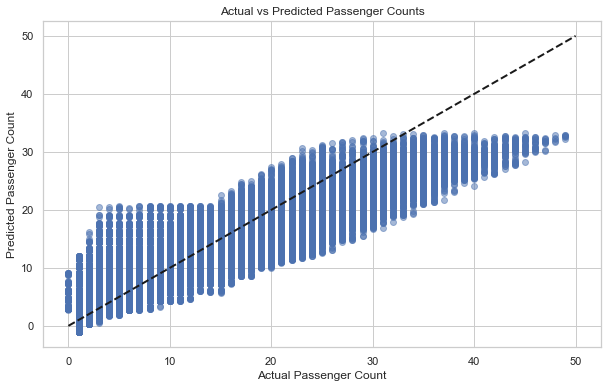

In [82]:
# Scatter plot of Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # Line representing perfect prediction
plt.xlabel('Actual Passenger Count')
plt.ylabel('Predicted Passenger Count')
plt.title('Actual vs Predicted Passenger Counts')
#plt.grid(True)
plt.show()


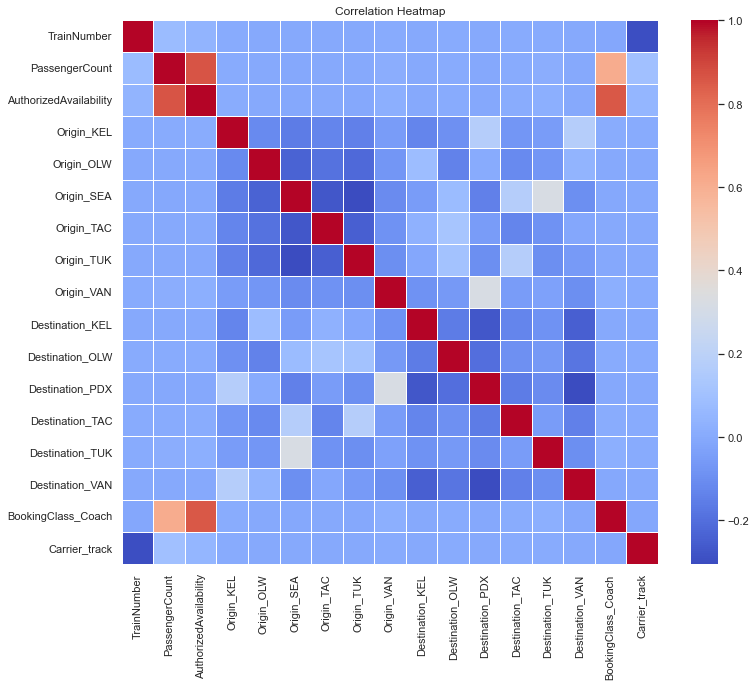

In [83]:
# Heatmap of correlations
plt.figure(figsize=(12, 10))
correlation_matrix = data_encoded.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()


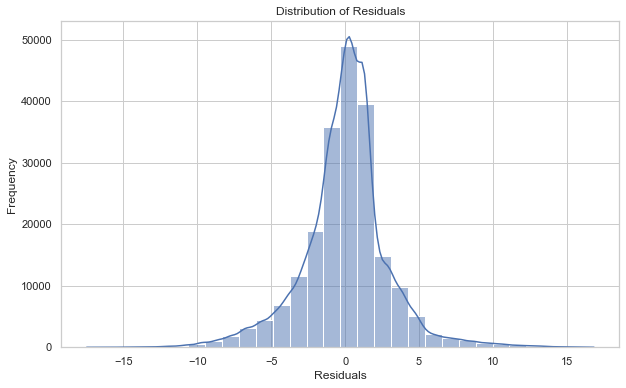

In [84]:
# Plot of residuals
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [85]:
# Convert TrainIndexDate to datetime format and aggregate daily passenger counts
data['ServiceDate'] = pd.to_datetime(data['ServiceDate'])
daily_passenger_counts = data.groupby('ServiceDate')['PassengerCount'].sum().reset_index()

daily_passenger_counts.head()


,ServiceDate,PassengerCount
0,2023-04-01,14906
1,2023-04-02,14945
2,2023-04-03,20974
3,2023-04-04,21267
4,2023-04-05,20877


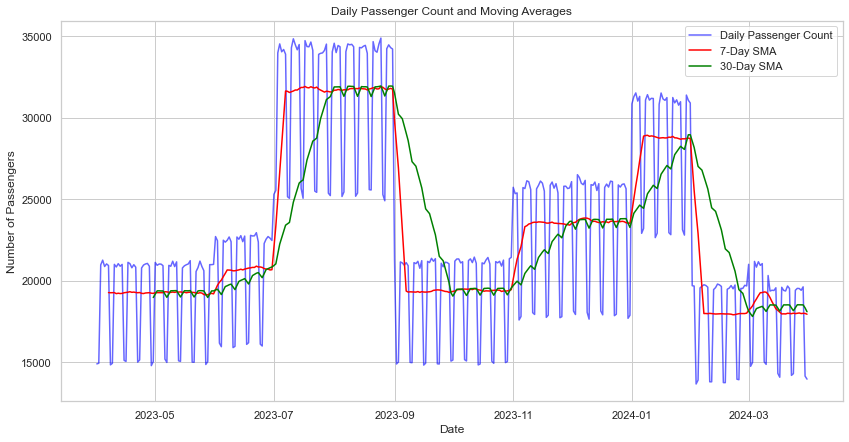

In [86]:
import matplotlib.pyplot as plt

# Calculate simple moving averages for 7-day and 30-day windows
daily_passenger_counts['7-Day SMA'] = daily_passenger_counts['PassengerCount'].rolling(window=7).mean()
daily_passenger_counts['30-Day SMA'] = daily_passenger_counts['PassengerCount'].rolling(window=30).mean()

# Plotting the results
plt.figure(figsize=(14, 7))
plt.plot(daily_passenger_counts['ServiceDate'], daily_passenger_counts['PassengerCount'], label='Daily Passenger Count', color='blue', alpha=0.6)
plt.plot(daily_passenger_counts['ServiceDate'], daily_passenger_counts['7-Day SMA'], label='7-Day SMA', color='red')
plt.plot(daily_passenger_counts['ServiceDate'], daily_passenger_counts['30-Day SMA'], label='30-Day SMA', color='green')

plt.title('Daily Passenger Count and Moving Averages')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()


In [17]:
# Remove rows with NaN values that result from calculating the SMAs
valid_data = daily_passenger_counts.dropna(subset=['7-Day SMA', '30-Day SMA'])

# Calculate R-squared for 7-Day SMA and 30-Day SMA
r_squared_7 = r2_score(valid_data['PassengerCount'], valid_data['7-Day SMA'])
r_squared_30 = r2_score(valid_data['PassengerCount'], valid_data['30-Day SMA'])

# Calculate adjusted R-squared
n = len(valid_data)  # number of data points
k = 1  # number of predictors
adjusted_r_squared_7 = 1 - ((1 - r_squared_7) * (n - 1) / (n - k - 1))
adjusted_r_squared_30 = 1 - ((1 - r_squared_30) * (n - 1) / (n - k - 1))

r_squared_7, r_squared_30, adjusted_r_squared_7, adjusted_r_squared_30


(0.5980380994455734,
 0.36997945234232255,
 0.5968382131752616,
 0.36809879399110557)

<font size="5">Simple Moving Average Method weekdays  --week based predictions<font size="5">

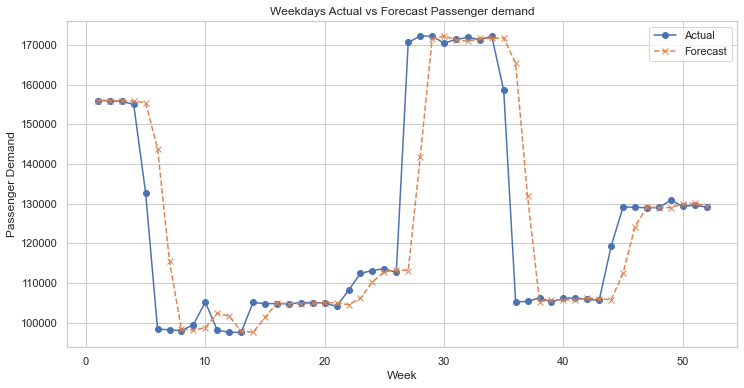

In [87]:
warnings.filterwarnings('ignore')
# Ensure 'TrainIndexDate' is in datetime format and filter weekdays
data['ServiceDate'] = pd.to_datetime(data['ServiceDate'])
weekday_data = data[data['ServiceDate'].dt.dayofweek < 5]  # Filter out weekends

# Calculate the total passenger counts per week
weekday_data['week'] = weekday_data['ServiceDate'].dt.isocalendar().week
weekly_actual = weekday_data.groupby('week')['PassengerCount'].sum().reset_index()

# Calculate the forecast using simple moving average of the actuals
weekly_actual['forecast'] = weekly_actual['PassengerCount'].rolling(window=2, min_periods=1).mean().shift(1)

# Ensuring that the forecast doesn't include the first week's NaN
weekly_actual.fillna(0, inplace=True)
weekly_actual['forecast'] = weekly_actual['forecast'].astype(int)

# Show the resulting dataframe
weekly_actual.head(10)  # Displaying first 10 weeks for preview

weekly_actual.loc[weekly_actual['forecast'] == 0, 'forecast'] = weekly_actual['PassengerCount']
import matplotlib.pyplot as plt

# Plotting the line graph for actual vs forecast passenger counts
plt.figure(figsize=(12, 6))
plt.plot(weekly_actual['week'], weekly_actual['PassengerCount'], label='Actual', marker='o')
plt.plot(weekly_actual['week'], weekly_actual['forecast'], label='Forecast', marker='x', linestyle='--')
plt.title('Weekdays Actual vs Forecast Passenger demand')
plt.xlabel('Week')
plt.ylabel('Passenger Demand')
plt.legend()
#plt.grid(True)
plt.show()

<font size="5">Simple Moving Average Method weekend  --week based predictions<font size="5">

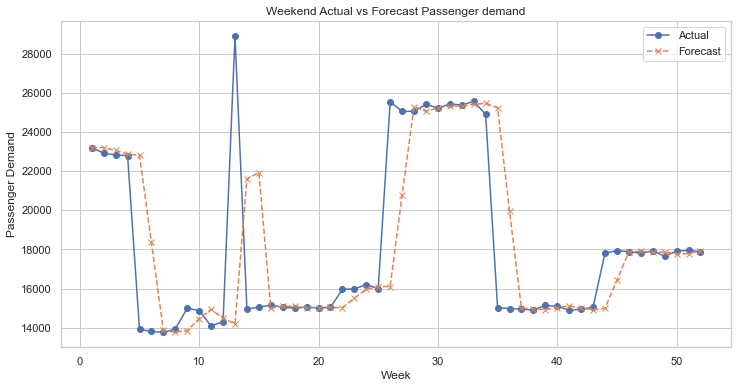

In [88]:
warnings.filterwarnings('ignore')
# Ensure 'TrainIndexDate' is in datetime format and filter weekdays
data['ServiceDate'] = pd.to_datetime(data['ServiceDate'])
weekday_data = data[data['ServiceDate'].dt.dayofweek > 5]  # Filter out weekends

# Calculate the total passenger counts per week
weekday_data['week'] = weekday_data['ServiceDate'].dt.isocalendar().week
weekly_actual = weekday_data.groupby('week')['PassengerCount'].sum().reset_index()

# Calculate the forecast using simple moving average of the actuals
weekly_actual['forecast'] = weekly_actual['PassengerCount'].rolling(window=2, min_periods=1).mean().shift(1)

# Ensuring that the forecast doesn't include the first week's NaN
weekly_actual.fillna(0, inplace=True)
weekly_actual['forecast'] = weekly_actual['forecast'].astype(int)

# Show the resulting dataframe
weekly_actual.head(10)  # Displaying first 10 weeks for preview


weekly_actual.loc[weekly_actual['forecast'] == 0, 'forecast'] = weekly_actual['PassengerCount']
import matplotlib.pyplot as plt

# Plotting the line graph for actual vs forecast passenger counts
plt.figure(figsize=(12, 6))
plt.plot(weekly_actual['week'], weekly_actual['PassengerCount'], label='Actual', marker='o')
plt.plot(weekly_actual['week'], weekly_actual['forecast'], label='Forecast', marker='x', linestyle='--')
plt.title('Weekend Actual vs Forecast Passenger demand')
plt.xlabel('Week')
plt.ylabel('Passenger Demand')
plt.legend()
#plt.grid(True)
plt.show()


<font size="5">Simple Moving Average Method weekdays -'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'<font size="5">

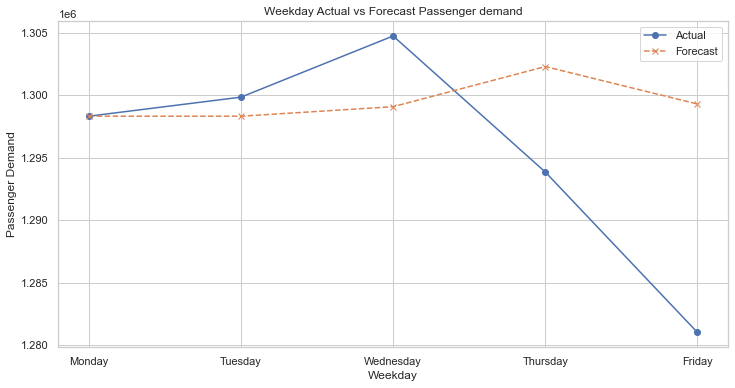

In [89]:
# Ensure 'TrainIndexDate' is in datetime format and filter weekdays
data['ServiceDate'] = pd.to_datetime(data['ServiceDate'])
weekday_data = data[(data['ServiceDate'].dt.dayofweek < 5)
#                     & 
#                     (data['OriginLocationCode'] == 'SEA') & 
#                     (data['DestinationCode'] == 'PDX')
                   ]  # Filter for SEA to PDX on weekdays

# Calculate the total passenger counts per weekday
weekday_data['weekday'] = weekday_data['ServiceDate'].dt.day_name()
weekday_actual = weekday_data.groupby('weekday')['PassengerCount'].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']).reset_index()

# Calculate the forecast using simple moving average of the actuals
weekday_actual['forecast'] = weekday_actual['PassengerCount'].rolling(window=2, min_periods=1).mean().shift(1)

# Ensuring that the forecast doesn't include the first weekday's NaN
weekday_actual.fillna(0, inplace=True)
weekday_actual['forecast'] = weekday_actual['forecast'].astype(int)


weekday_actual.loc[weekday_actual['forecast'] == 0, 'forecast'] = weekday_actual['PassengerCount']
import matplotlib.pyplot as plt

# Plotting the line graph for actual vs forecast passenger counts
plt.figure(figsize=(12, 6))
plt.plot(weekday_actual['weekday'], weekday_actual['PassengerCount'], label='Actual', marker='o')
plt.plot(weekday_actual['weekday'], weekday_actual['forecast'], label='Forecast', marker='x', linestyle='--')
plt.title('Weekday Actual vs Forecast Passenger demand')
plt.xlabel('Weekday')
plt.ylabel('Passenger Demand')
plt.legend()
#plt.grid(True)
plt.show()



<font size="5">Simple Moving Average Method weekend<font size="5">

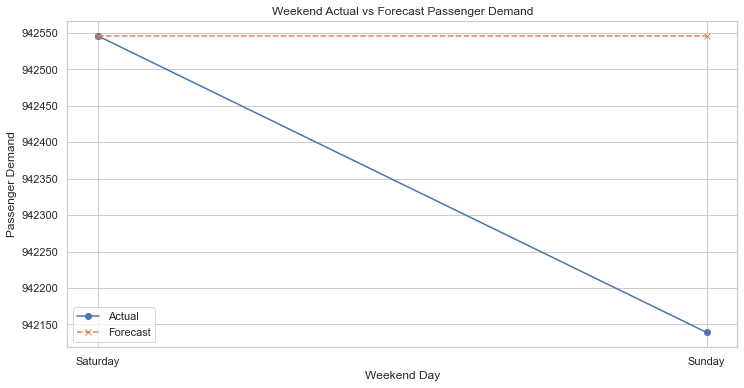

In [90]:
# Ensure 'TrainIndexDate' is in datetime format and filter for weekends
data['ServiceDate'] = pd.to_datetime(data['ServiceDate'])
weekend_data = data[(data['ServiceDate'].dt.dayofweek >= 5)]  # Filter for SEA to PDX on weekends

# Calculate the total passenger counts per weekend day
weekend_data['weekend'] = weekend_data['ServiceDate'].dt.day_name()
weekend_actual = weekend_data.groupby('weekend')['PassengerCount'].sum().reindex(['Saturday', 'Sunday']).reset_index()

# Calculate the forecast using simple moving average of the actuals
weekend_actual['forecast'] = weekend_actual['PassengerCount'].rolling(window=2, min_periods=1).mean().shift(1)

# Ensuring that the forecast doesn't include the first weekend day's NaN
weekend_actual.fillna(0, inplace=True)
weekend_actual['forecast'] = weekend_actual['forecast'].astype(int)

# Handle cases where the forecast is zero
weekend_actual.loc[weekend_actual['forecast'] == 0, 'forecast'] = weekend_actual['PassengerCount']

# Plotting the line graph for actual vs forecast passenger counts
plt.figure(figsize=(12, 6))
plt.plot(weekend_actual['weekend'], weekend_actual['PassengerCount'], label='Actual', marker='o')
plt.plot(weekend_actual['weekend'], weekend_actual['forecast'], label='Forecast', marker='x', linestyle='--')
plt.title('Weekend Actual vs Forecast Passenger Demand')
plt.xlabel('Weekend Day')
plt.ylabel('Passenger Demand')
plt.legend()
#plt.grid(True)
plt.show()

<font size="5">Regression Method for weekdays<font size="5">

In [91]:
# Convert 'TrainIndexDate' to datetime and filter for weekdays only
data['ServiceDate'] = pd.to_datetime(data['ServiceDate'])
weekday_data = data[data['ServiceDate'].dt.dayofweek < 5]  # Monday to Friday

# Aggregate passenger counts by weekday
weekday_passenger_data = weekday_data.groupby(weekday_data['ServiceDate'].dt.day_name())['PassengerCount'].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']).reset_index()

# Rename columns for clarity
weekday_passenger_data.columns = ['Weekday', 'PassengerCount']

# Prepare the data for regression: encode weekdays as numerical data
weekday_mapping = {day: i for i, day in enumerate(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])}
X_weekday = weekday_passenger_data['Weekday'].map(weekday_mapping).values.reshape(-1, 1)

# Fit the linear regression model
model_weekday = LinearRegression()
model_weekday.fit(X_weekday, weekday_passenger_data['PassengerCount'])

# Forecast passenger counts using the model
weekday_passenger_data['Forecast'] = model_weekday.predict(X_weekday).astype(int)

# Display the results
print(weekday_passenger_data)


     Weekday  PassengerCount  Forecast
0     Monday         1298327   1303682
1    Tuesday         1299852   1299621
2  Wednesday         1304747   1295561
3   Thursday         1293857   1291500
4     Friday         1281022   1287440


In [93]:

# Convert 'TrainIndexDate' to datetime and filter for weekends only
data['ServiceDate'] = pd.to_datetime(data['ServiceDate'])
weekend_data = data[data['ServiceDate'].dt.dayofweek >= 5]  # Saturday and Sunday

# Aggregate passenger counts by day of the week
weekend_passenger_data = weekend_data.groupby(weekend_data['ServiceDate'].dt.day_name())['PassengerCount'].sum().reindex(
    ['Saturday', 'Sunday']).reset_index()

# Rename columns for clarity
weekend_passenger_data.columns = ['Weekend', 'PassengerCount']

# Prepare the data for regression: encode days as numerical data
weekday_mapping = {day: i for i, day in enumerate(['Saturday', 'Sunday'])}
X_weekend = weekend_passenger_data['Weekend'].map(weekday_mapping).values.reshape(-1, 1)

# Fit the linear regression model
model_weekend = LinearRegression()
model_weekend.fit(X_weekend, weekend_passenger_data['PassengerCount'])

# Forecast passenger counts using the model
weekend_passenger_data['Forecast'] = model_weekend.predict(X_weekend).astype(int)

# Display the results
print(weekend_passenger_data)

    Weekend  PassengerCount  Forecast
0  Saturday          942546    942546
1    Sunday          942139    942139


<font size="5">MAPE for regression and simple moving agerage<font size="5">

<font size="5">Model Data preparattion<font size="5">

In [99]:
# Load the data
data_path = '/mnt/data/passenger_demand.csv'
data = pd.read_csv(data_path)
data = data[(data['Origin'] == 'SEA') & (data['Destination'] == 'PDX')]

# Selecting features and target
X = data[['TrainNumber', 'Origin', 'Destination', 'BookingClass', 'ServiceDate', 'StartTime', 'Carrier']]
y = data['PassengerCount']

# Preprocessing: One-hot encoding for categorical variables and scaling for numeric input
categorical_features = ['TrainNumber', 'Origin', 'Destination', 'BookingClass', 'ServiceDate', 'StartTime', 'Carrier']
numeric_features = ['TrainNumber']


<font size="5">ANN Model<font size="5">

In [98]:
results_df = pd.DataFrame(columns=['Model', 'MAE', 'MSE', 'RMSE', 'MAPE', 'Bias'])

In [100]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Splitting data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create an ANN model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42))
])

# Train the model
model.fit(X_train, y_train)

# Predicting the test set
y_pred = model.predict(X_test)

# Metrics
mae_ann = mean_absolute_error(y_test, y_pred)
mse_ann = mean_squared_error(y_test, y_pred)
rmse_ann = np.sqrt(mse)
mape_ann = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
bias_ann = np.mean(y_pred - y_test)

#mae_ann, mse_ann, rmse_ann, mape_ann, bias_ann

name = 'ANN'
results_df = results_df.append({'Model': name, 'MAE': mae_ann, 'MSE': mse_ann, 'RMSE': rmse_ann, 'MAPE': mape_ann, 'Bias': bias_ann}, ignore_index=True)
print(results_df)

  Model       MAE        MSE      RMSE MAPE      Bias
0   ANN  3.806828  29.431205  2.949764  inf  0.041147


<font size="5">SVM model<font size="5">

In [62]:
from sklearn.svm import SVR

# Create an SVM model with the same preprocessing
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SVR(C=1.0, epsilon=0.2))
])

# Train the SVM model
svm_model.fit(X_train, y_train)

# Predicting the test set with SVM
y_pred_svm = svm_model.predict(X_test)

# Metrics for SVM
mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
mape_svm = np.mean(np.abs((y_test - y_pred_svm) / y_test)) * 100
bias_svm = np.mean(y_pred_svm - y_test)

#mae_svm, mse_svm, rmse_svm, mape_svm, bias_svm


name = 'SVM'
results_df = results_df.append({'Model': name, 'MAE': mae_svm, 'MSE': mse_svm, 'RMSE': rmse_svm, 'MAPE': mape_svm, 'Bias': bias_svm}, ignore_index=True)
print(results_df)

  Model       MAE        MSE      RMSE MAPE      Bias
0   ANN  3.718698  28.644852  2.992518  inf -0.188493
1   SVM  3.400199  26.061924  5.105088  inf -0.726161


<font size="5">Random Forest<font size="5">

In [63]:
from sklearn.ensemble import RandomForestRegressor

# Create a Random Forest model with the same preprocessing
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train the Random Forest model
rf_model.fit(X_train, y_train)

# Predicting the test set with Random Forest
y_pred_rf = rf_model.predict(X_test)

# Metrics for Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
bias_rf = np.mean(y_pred_rf - y_test)

#mae_rf, mse_rf, rmse_rf, mape_rf, bias_rf

name = 'Random Forest'
results_df = results_df.append({'Model': name, 'MAE': mae_rf, 'MSE': mse_rf, 'RMSE': rmse_rf, 'MAPE': mape_rf, 'Bias': bias_rf}, ignore_index=True)
print(results_df)

           Model       MAE        MSE      RMSE MAPE      Bias
0            ANN  3.718698  28.644852  2.992518  inf -0.188493
1            SVM  3.400199  26.061924  5.105088  inf -0.726161
2  Random Forest   4.52921  41.616144  6.451058  inf -0.047327


<font size="5">Linear Regression Model<font size="5">

In [64]:
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model with the same preprocessing
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the Linear Regression model
lr_model.fit(X_train, y_train)

# Predicting the test set with Linear Regression
y_pred_lr = lr_model.predict(X_test)

# Metrics for Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100
bias_lr = np.mean(y_pred_lr - y_test)

#mae_lr, mse_lr, rmse_lr, mape_lr, bias_lr

name = 'Linear Regression'
results_df = results_df.append({'Model': name, 'MAE': mae_lr, 'MSE': mse_lr, 'RMSE': rmse_lr, 'MAPE': mape_lr, 'Bias': bias_lr}, ignore_index=True)
print(results_df)

               Model       MAE        MSE      RMSE MAPE      Bias
0                ANN  3.718698  28.644852  2.992518  inf -0.188493
1                SVM  3.400199  26.061924  5.105088  inf -0.726161
2      Random Forest   4.52921  41.616144  6.451058  inf -0.047327
3  Linear Regression  3.453235  24.005584  4.899549  inf -0.017597


<font size="5">polynomial regression<font size="5">

In [65]:
from sklearn.preprocessing import PolynomialFeatures

# Create a Polynomial Regression model with preprocessing
# Adding polynomial features with degree 2
poly_preprocessor = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly_features', PolynomialFeatures(degree=2))
])

poly_model = Pipeline(steps=[
    ('poly_preprocessor', poly_preprocessor),
    ('regressor', LinearRegression())
])

# Train the Polynomial Regression model
poly_model.fit(X_train, y_train)

# Predicting the test set with Polynomial Regression
y_pred_poly = poly_model.predict(X_test)

# Metrics for Polynomial Regression
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mape_poly = np.mean(np.abs((y_test - y_pred_poly) / y_test)) * 100
bias_poly = np.mean(y_pred_poly - y_test)

#mae_poly, mse_poly, rmse_poly, mape_poly, bias_poly

name = 'Polynomial Regression'
results_df = results_df.append({'Model': name, 'MAE': mae_poly, 'MSE': mse_poly, 'RMSE': rmse_poly, 'MAPE': mape_poly, 'Bias': bias_poly}, ignore_index=True)
print(results_df)

                   Model       MAE        MSE      RMSE MAPE      Bias
0                    ANN  3.718698  28.644852  2.992518  inf -0.188493
1                    SVM  3.400199  26.061924  5.105088  inf -0.726161
2          Random Forest   4.52921  41.616144  6.451058  inf -0.047327
3      Linear Regression  3.453235  24.005584  4.899549  inf -0.017597
4  Polynomial Regression  3.588261  25.747677  5.074217  inf  -0.00958


<font size="5">decision tree model<font size="5">

In [66]:
from sklearn.tree import DecisionTreeRegressor

# Create a Decision Tree model with preprocessing
dt_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# Train the Decision Tree model
dt_model.fit(X_train, y_train)

# Predicting the test set with Decision Tree
y_pred_dt = dt_model.predict(X_test)

# Metrics for Decision Tree
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
mape_dt = np.mean(np.abs((y_test - y_pred_dt) / y_test)) * 100
bias_dt = np.mean(y_pred_dt - y_test)

#mae_dt, mse_dt, rmse_dt, mape_dt, bias_dt

name = 'Decision Tree'
results_df = results_df.append({'Model': name, 'MAE': mae_dt, 'MSE': mse_dt, 'RMSE': rmse_dt, 'MAPE': mape_dt, 'Bias': bias_dt}, ignore_index=True)
print(results_df)

                   Model       MAE        MSE      RMSE MAPE      Bias
0                    ANN  3.718698  28.644852  2.992518  inf -0.188493
1                    SVM  3.400199  26.061924  5.105088  inf -0.726161
2          Random Forest   4.52921  41.616144  6.451058  inf -0.047327
3      Linear Regression  3.453235  24.005584  4.899549  inf -0.017597
4  Polynomial Regression  3.588261  25.747677  5.074217  inf  -0.00958
5          Decision Tree  5.431652  60.352639  7.768696  inf -0.064612


<font size="5">Visalizaiton of model outcomes<font size="5">

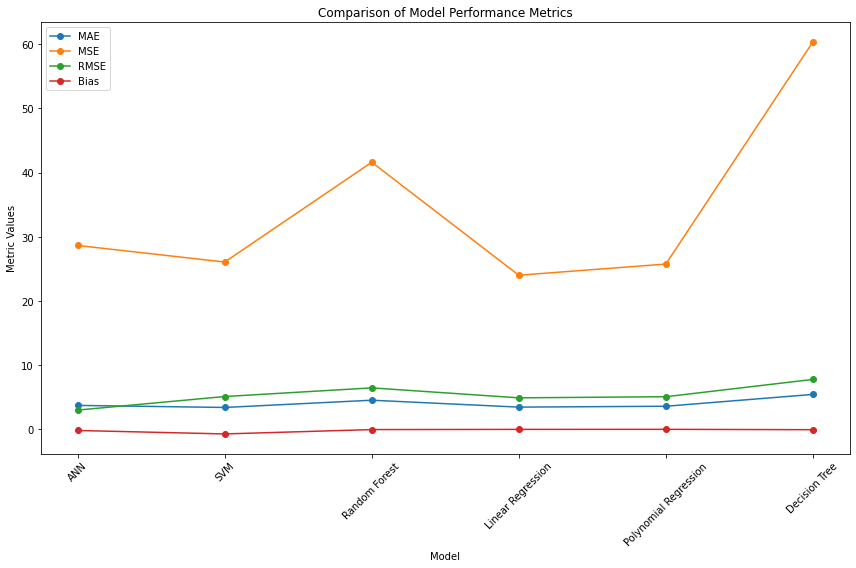

In [38]:
# Plotting the metrics
plt.figure(figsize=(12, 8))
for metric in ['MAE', 'MSE', 'RMSE', 'Bias']:
    plt.plot(results_df['Model'], results_df[metric], marker='o', label=metric)
plt.title('Comparison of Model Performance Metrics')
plt.xlabel('Model')
plt.ylabel('Metric Values')
plt.legend()
#plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<font size="5">station based demand<font size="5">

In [102]:
data_path = '/mnt/data/passenger_demand.csv'
passenger_data = pd.read_csv(data_path)
# Aggregate passenger counts by origin location code
passenger_summary = passenger_data.groupby('Origin')['PassengerCount'].sum().reset_index()

# Prepare features and target variable
X = np.array(passenger_summary.index).reshape(-1, 1)  # Using index as a feature
y = passenger_summary['PassengerCount'].values

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the ANN model
mlp = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Predict on the entire data set
X_all_scaled = scaler.transform(np.arange(len(passenger_summary)).reshape(-1, 1))
y_pred = mlp.predict(X_all_scaled)

# Generate forecasts as actual +/- random variation of forecast
variation = np.random.normal(loc=0.0, scale=0.1, size=y_pred.shape) * y_pred
forecast_final = y + variation

# Convert forecast values to integers
forecast_final = forecast_final.astype(int)

# Create DataFrame to show results
results_df = pd.DataFrame({
    "Origin": passenger_summary['Origin'],
    "Actual": passenger_summary['PassengerCount'],
    "Forecast": forecast_final
})

print(results_df)

  Origin   Actual  Forecast
0    CTL   894077    894656
1    KEL   592294    592077
2    OLW  1194977   1194883
3    SEA  2096603   2096694
4    TAC  1496596   1496734
5    TUK  1797316   1797325
6    VAN   290627    290783


<font size="5">Models performance for all the models for passenger demand origin Seattle and destination Portland<font size="5">

In [103]:

# Filter data for SEA to PDX trips
filtered_data = data[(data['Origin'] == 'SEA') & (data['Destination'] == 'PDX')]

# Convert 'TrainIndexDate' to datetime format
filtered_data['ServiceDate'] = pd.to_datetime(filtered_data['ServiceDate'])

# Aggregate data by 'TrainIndexDate' to sum up daily passenger counts
daily_passengers = filtered_data.groupby('ServiceDate')['PassengerCount'].sum().reset_index()

# Prepare data for modeling
X = np.array(daily_passengers['ServiceDate'].map(pd.Timestamp.toordinal)).reshape(-1, 1)
y = daily_passengers['PassengerCount'].values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Define models
models = {
    "ANN": MLPRegressor(random_state=1, max_iter=500),
    "SVM": SVR(),
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=1),
    "Polynomial Regression": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    "Decision Tree": DecisionTreeRegressor(random_state=1)
}

# Train models and predict
model_predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    model_predictions[name] = model.predict(X_test)

# Convert ordinal dates back to datetime for presentation
test_dates = [datetime.fromordinal(int(date)) for date in X_test.flatten()]

# Compile results from all models into a DataFrame for comparison
results_df = pd.DataFrame({"Date": test_dates, "Actual": y_test})
for model_name, predictions in model_predictions.items():
    results_df[model_name + " Forecast"] = predictions

# Display results
print(results_df.head())


        Date  Actual  ANN Forecast  SVM Forecast  Linear Regression Forecast  \
0 2024-01-18    1159    849.642114    816.877937                  914.727016   
1 2024-01-19    1144    849.643264    816.866169                  915.209093   
2 2024-01-20     838    849.644413    816.845601                  915.691170   
3 2024-01-21     855    849.645563    816.816355                  916.173247   
4 2024-01-22    1042    849.646712    816.778560                  916.655324   

   Random Forest Forecast  Polynomial Regression Forecast  \
0                 1080.47                      812.526194   
1                 1080.47                      810.915416   
2                 1080.47                      809.290403   
3                 1080.47                      807.651151   
4                 1080.47                      805.997663   

   Decision Tree Forecast  
0                  1080.0  
1                  1080.0  
2                  1080.0  
3                  1080.0  
4           

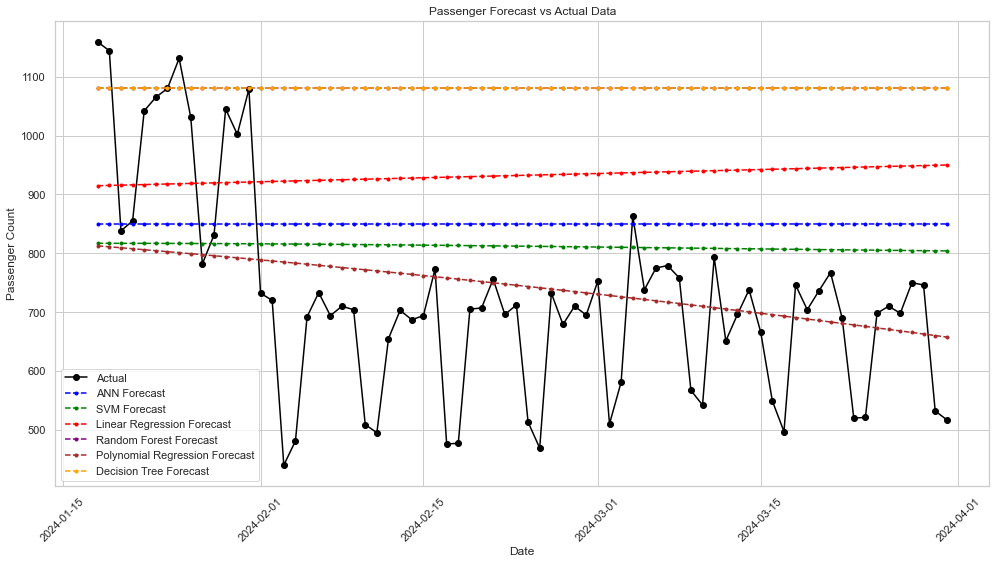

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style of seaborn
sns.set(style="whitegrid")

# Plot size
plt.figure(figsize=(14, 8))

# Plotting actual data
plt.plot(results_df['Date'], results_df['Actual'], label='Actual', color='black', marker='o', linestyle='-')

# Plotting forecasts for each model
colors = ['blue', 'green', 'red', 'purple', 'brown', 'orange']
for i, (model_name, color) in enumerate(zip(models.keys(), colors)):
    plt.plot(results_df['Date'], results_df[model_name + ' Forecast'], label=model_name + ' Forecast', color=color, marker='.', linestyle='--')

# Adding title and labels
plt.title('Passenger Forecast vs Actual Data')
plt.xlabel('Date')
plt.ylabel('Passenger Count')
plt.xticks(rotation=45)  # Rotate date labels for better readability

# Adding legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [130]:
import pandas as pd

# Assuming data is loaded into a DataFrame named 'data'
data = pd.read_csv('/mnt/data/passenger_demand.csv')
#data_path = 'C:\\Users\\sanve\\Documents\\CP\\data\\passenger_demand.csv'
print(data.head())

data.dtypes

filtered_df = data[
    (data['TrainNumber'] == 503) &
    (data['StartTime'] == '5:00') &
    (data['Origin'] == 'SEA')
]
print(filtered_df.head())

   TrainNumber Origin Destination BookingClass  PassengerCount ServiceDate  \
0          503    SEA         TUK        Coach               7    4/1/2023   
1          503    SEA         TUK     Business               3    4/1/2023   
2          503    SEA         TAC        Coach               8    4/1/2023   
3          503    SEA         TAC     Business               2    4/1/2023   
4          503    SEA         OLW        Coach              11    4/1/2023   

  StartTime Carrier  AuthorizedAvailability  
0      5:00   track                    11.0  
1      5:00   track                     4.0  
2      5:00   track                    11.0  
3      5:00   track                     3.0  
4      5:00   track                    15.0  
   TrainNumber Origin Destination BookingClass  PassengerCount ServiceDate  \
0          503    SEA         TUK        Coach               7    4/1/2023   
1          503    SEA         TUK     Business               3    4/1/2023   
2          503    SEA

In [118]:



# Convert 'StartTime' to string if it's not already, this step might be unnecessary depending on your data
data['StartTime'] = data['StartTime'].astype(str)

# Filter for TrainNumber 503 and StartTime at 5 AM
filtered_data = data[(data['StartTime'] == '05:00 AM')]
print(filtered_data.head())

Empty DataFrame
Columns: [TrainNumber, Origin, Destination, BookingClass, PassengerCount, ServiceDate, StartTime, Carrier, AuthorizedAvailability]
Index: []


<font size="5">Predictions for Passengers boarding in Seattle station <font size="5">

In [136]:

# Filter data for SEA to PDX trips
filtered_data = data[(data['Origin'] == 'SEA') & (data['TrainNumber'] == 503) & (data['StartTime'] == '5:00')]

# Convert 'TrainIndexDate' to datetime format
filtered_data['ServiceDate'] = pd.to_datetime(filtered_data['ServiceDate'])

# Aggregate data by 'TrainIndexDate' to sum up daily passenger counts
daily_passengers = filtered_data.groupby('ServiceDate')['PassengerCount'].sum().reset_index()

# Prepare data for modeling
X = np.array(daily_passengers['ServiceDate'].map(pd.Timestamp.toordinal)).reshape(-1, 1)
y = daily_passengers['PassengerCount'].values

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Define models
models = {
    "ANN": MLPRegressor(random_state=1, max_iter=500),
    "SVM": SVR(),
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=1),
    "Polynomial Regression": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    "Decision Tree": DecisionTreeRegressor(random_state=1)
}

# Train models and predict
model_predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    model_predictions[name] = model.predict(X_test)

# Convert ordinal dates back to datetime for presentation
test_dates = [datetime.fromordinal(int(date)) for date in X_test.flatten()]

# Compile results from all models into a DataFrame for comparison
results_df = pd.DataFrame({"Date": test_dates, "Actual": y_test})
for model_name, predictions in model_predictions.items():
    results_df[model_name + " Forecast"] = predictions

# Display results
print(results_df.head())


        Date  Actual  ANN Forecast  SVM Forecast  Linear Regression Forecast  \
0 2024-01-18     292    218.786810    219.638447                  229.690510   
1 2024-01-19     247    218.787106    219.642020                  229.821082   
2 2024-01-20     235    218.787402    219.638612                  229.951655   
3 2024-01-21     204    218.787697    219.628314                  230.082227   
4 2024-01-22     248    218.787993    219.611226                  230.212800   

   Random Forest Forecast  Polynomial Regression Forecast  \
0                   267.8                      201.258404   
1                   267.8                      200.806749   
2                   267.8                      200.351134   
3                   267.8                      199.891557   
4                   267.8                      199.428020   

   Decision Tree Forecast  
0                   260.0  
1                   260.0  
2                   260.0  
3                   260.0  
4           

<font size="5"> Passenger demand for train 503, 5am service and boarding Seattle station<font size="5">

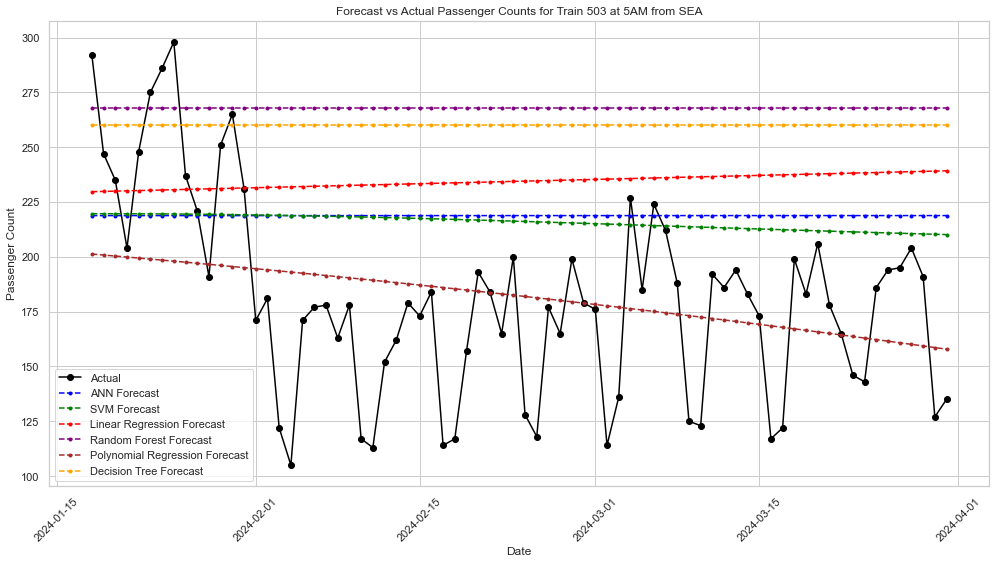

In [137]:
# Set the style of seaborn
sns.set(style="whitegrid")

# Plot size
plt.figure(figsize=(14, 8))

# Plotting actual data
plt.plot(results_df['Date'], results_df['Actual'], label='Actual', color='black', marker='o', linestyle='-')

# Plotting forecasts for each model
colors = ['blue', 'green', 'red', 'purple', 'brown', 'orange']
for i, (model_name, color) in enumerate(zip(models.keys(), colors)):
    plt.plot(results_df['Date'], results_df[model_name + ' Forecast'], label=model_name + ' Forecast', color=color, marker='.', linestyle='--')

# Adding title and labels
plt.title('Forecast vs Actual Passenger Counts for Train 503 at 5AM from SEA')
plt.xlabel('Date')
plt.ylabel('Passenger Count')
plt.xticks(rotation=45)  # Rotate date labels for better readability

# Adding legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()
